In [2]:
from google.colab import files
uploaded = files.upload()

Saving fashion-mnist_train.csv to fashion-mnist_train.csv
Saving fashion-mnist_test.csv to fashion-mnist_test.csv


In [3]:
import pandas as pd

train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Drop label column
x_train = train_df.drop('label', axis=1).values
x_test = test_df.drop('label', axis=1).values

# Labels not needed for autoencoder

In [5]:
import numpy as np

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape into 28x28 images
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

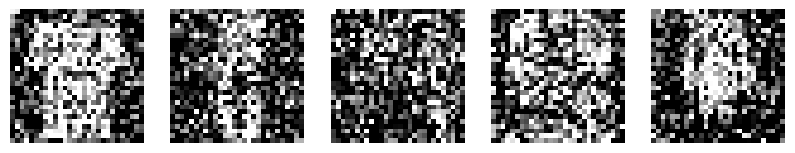

In [8]:
import matplotlib.pyplot as plt

n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

In [10]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [11]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 249ms/step - loss: 0.3402 - val_loss: 0.3108
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.3092 - val_loss: 0.3056
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.3058 - val_loss: 0.3033
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 238ms/step - loss: 0.3038 - val_loss: 0.3020
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 243ms/step - loss: 0.3023 - val_loss: 0.3003


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


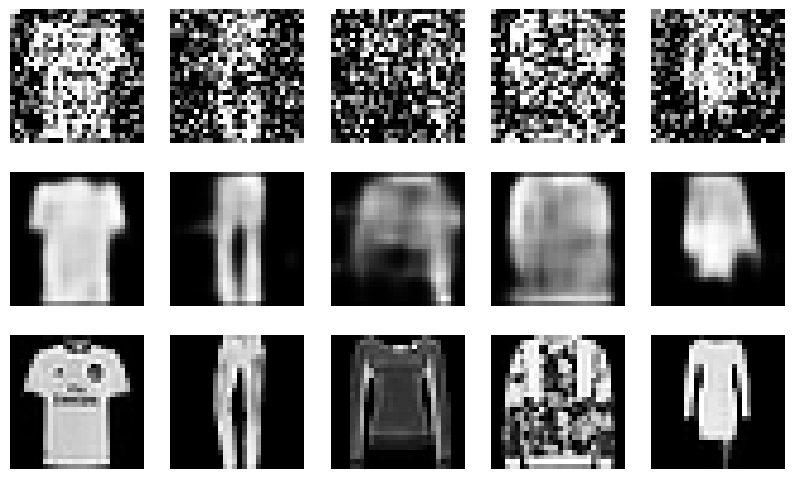

In [12]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 5
plt.figure(figsize=(10,6))

for i in range(n):
    # Noisy
    plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Original
    plt.subplot(3, n, i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()